# 🤖 AI Hand Gesture Recognition using CNN

### Internship Task 04

**Objective**

Develop a Convolutional Neural Network (CNN) capable of recognizing and classifying different hand gestures from image data, enabling gesture-based human-computer interaction.

---

### Technologies Used

- Python
- TensorFlow / Keras
- OpenCV
- NumPy
- Pandas
- Matplotlib
- Scikit-learn
- Streamlit

---

### Workflow

1. Import Libraries
2. Load Dataset
3. Explore Dataset
4. Preprocess Images
5. Train CNN Model
6. Evaluate Performance
7. Save Model
8. Deploy using Streamlit

In [1]:
import os
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense
)
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

In [2]:
print("=" * 50)
print("Environment Check")
print("=" * 50)

print("TensorFlow :", tf.__version__)
print("OpenCV     :", cv2.__version__)
print("NumPy      :", np.__version__)
print("Pandas     :", pd.__version__)

Environment Check
TensorFlow : 2.21.0
OpenCV     : 5.0.0
NumPy      : 2.2.6
Pandas     : 2.3.3


## 📂 Step 1: Load the Dataset

In this step, we define the dataset path and verify that the dataset is correctly loaded into the project.

In [8]:
dataset_path = Path("dataset/HandGesture/images")

print("Dataset Exists :", dataset_path.exists())
print("Dataset Path   :", dataset_path.resolve())

Dataset Exists : True
Dataset Path   : C:\Users\91821\Desktop\SCT_ML_04\dataset\HandGesture\images


## 📊 Step 2: Explore the Dataset

Let's inspect the gesture classes available in the dataset.

In [9]:
gesture_classes = sorted(
    [folder.name for folder in dataset_path.iterdir() if folder.is_dir()]
)

print(f"Total Gesture Classes : {len(gesture_classes)}\n")

for i, gesture in enumerate(gesture_classes, start=1):
    print(f"{i}. {gesture}")

Total Gesture Classes : 10

1. call_me
2. fingers_crossed
3. okay
4. paper
5. peace
6. rock
7. rock_on
8. scissor
9. thumbs
10. up


## 📥 Step 6: Load the Dataset

Load all gesture images, resize them, and prepare them for model training.

In [10]:
IMG_SIZE = 128

images = []
labels = []

for gesture in gesture_classes:

    folder = dataset_path / gesture

    for image_path in folder.glob("*"):

        image = cv2.imread(str(image_path))

        if image is None:
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

        images.append(image)
        labels.append(gesture)

print("Images Loaded Successfully!")
print("Total Images :", len(images))
print("Total Labels :", len(labels))

Images Loaded Successfully!
Total Images : 5243
Total Labels : 5243


## 🔄 Step 7: Convert Data into NumPy Arrays

In [11]:
images = np.array(images, dtype="float32")
labels = np.array(labels)

print("Images Shape :", images.shape)
print("Labels Shape :", labels.shape)

Images Shape : (5243, 128, 128, 3)
Labels Shape : (5243,)


## ⚙️ Step 8: Normalize the Images

In [12]:
images = images / 255.0

print("Minimum Pixel Value :", images.min())
print("Maximum Pixel Value :", images.max())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


## 🏷️ Step 9: Encode Gesture Labels

In [13]:
label_encoder = LabelEncoder()

labels_encoded = label_encoder.fit_transform(labels)

print("Gesture Classes:")
print(label_encoder.classes_)

Gesture Classes:
['call_me' 'fingers_crossed' 'okay' 'paper' 'peace' 'rock' 'rock_on'
 'scissor' 'thumbs' 'up']


## ✂️ Step 10: Split the Dataset

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels_encoded,
    test_size=0.20,
    random_state=42,
    stratify=labels_encoded
)

print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)

Training Images : (4194, 128, 128, 3)
Testing Images  : (1049, 128, 128, 3)


## 🧠 Step 11: Build the Convolutional Neural Network (CNN)

We will build a CNN consisting of convolutional layers, batch normalization, max pooling, dropout, and fully connected layers for robust hand gesture classification.

In [15]:
model = Sequential([

    Input(shape=(128, 128, 3)),

    Conv2D(32, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Dropout(0.30),

    Flatten(),

    Dense(256, activation="relu"),
    Dropout(0.50),

    Dense(len(gesture_classes), activation="softmax")

])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,519,498 (24.87 MB)

 Trainable params: 6,519,050 (24.87 MB)

 Non-trainable params: 448 (1.75 KB)

## ⚙️ Step 12: Compile the CNN Model

In [16]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 🛑 Step 13: Configure Early Stopping

Early stopping prevents overfitting by monitoring validation loss.

In [18]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

## 🚀 Step 14: Train the CNN Model

In [20]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.20,
   epochs=15,
batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 72s 688ms/step - accuracy: 0.5225 - loss: 1.6355 - val_accuracy: 0.0810 - val_loss: 57.4860
Epoch 2/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 67s 635ms/step - accuracy: 0.6957 - loss: 0.9653 - val_accuracy: 0.0810 - val_loss: 53.8394
Epoch 3/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 62s 594ms/step - accuracy: 0.7973 - loss: 0.6645 - val_accuracy: 0.2479 - val_loss: 12.9282
Epoch 4/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 63s 599ms/step - accuracy: 0.8364 - loss: 0.5511 - val_accuracy: 0.3707 - val_loss: 5.0419
Epoch 5/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 62s 595ms/step - accuracy: 0.8545 - loss: 0.4456 - val_accuracy: 0.8057 - val_loss: 0.8113
Epoch 6/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 63s 602ms/step - accuracy: 0.8844 - loss: 0.3997 - val_accuracy: 0.9273 - val_loss: 0.3284
Epoch 7/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 64s 606ms/step - accuracy: 0.9151 - loss: 0.2981 - val_accuracy: 0.9368 - val_loss: 0.2654
Epoch 8/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 63s 601ms/step - accuracy: 0.9183 - loss

## 📈 Step 15: Training and Validation Accuracy

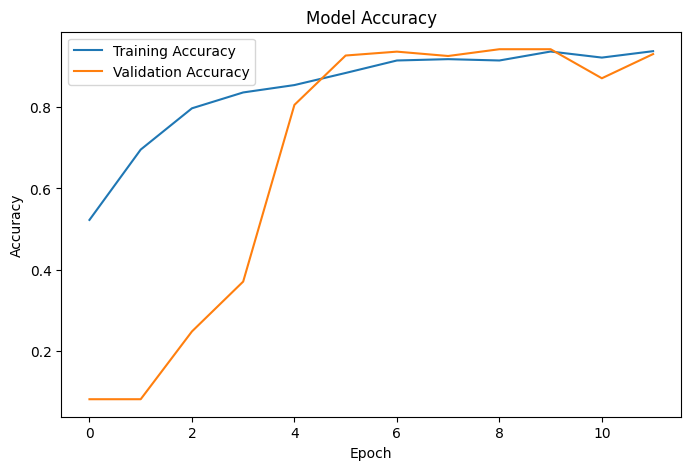

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## 📉 Step 16: Training and Validation Loss

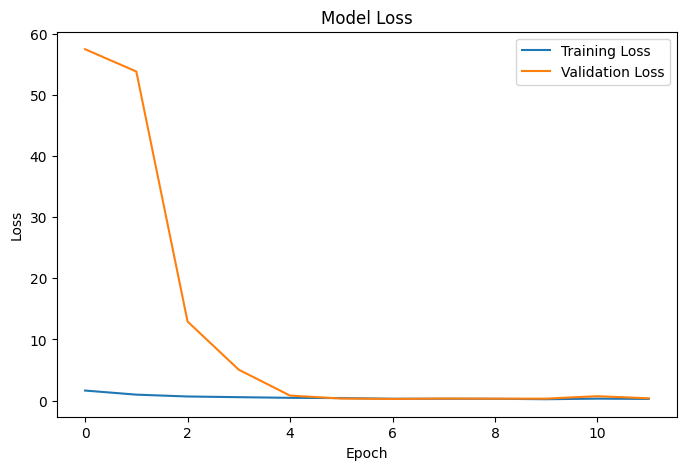

In [22]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## 📊 Step 17: Evaluate the Trained Model

Evaluate the CNN model on the unseen test dataset.

In [23]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("=" * 40)
print(f"Test Accuracy : {test_accuracy*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")
print("=" * 40)

Test Accuracy : 93.71%
Test Loss     : 0.2365


## 🔍 Step 18: Generate Predictions

In [24]:
y_pred_prob = model.predict(X_test, verbose=0)

y_pred = np.argmax(y_pred_prob, axis=1)

print("Prediction Shape :", y_pred.shape)

Prediction Shape : (1049,)


## 📑 Step 19: Classification Report

In [25]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

                 precision    recall  f1-score   support

        call_me       0.94      0.93      0.94       105
fingers_crossed       0.90      0.89      0.90       101
           okay       0.90      0.98      0.94       108
          paper       0.98      0.89      0.93       108
          peace       0.92      0.94      0.93       105
           rock       0.99      0.96      0.98       102
        rock_on       0.99      0.96      0.98       106
        scissor       0.84      0.90      0.87       105
         thumbs       0.95      0.96      0.95       108
             up       0.99      0.94      0.96       101

       accuracy                           0.94      1049
      macro avg       0.94      0.94      0.94      1049
   weighted avg       0.94      0.94      0.94      1049



## 📉 Step 20: Confusion Matrix

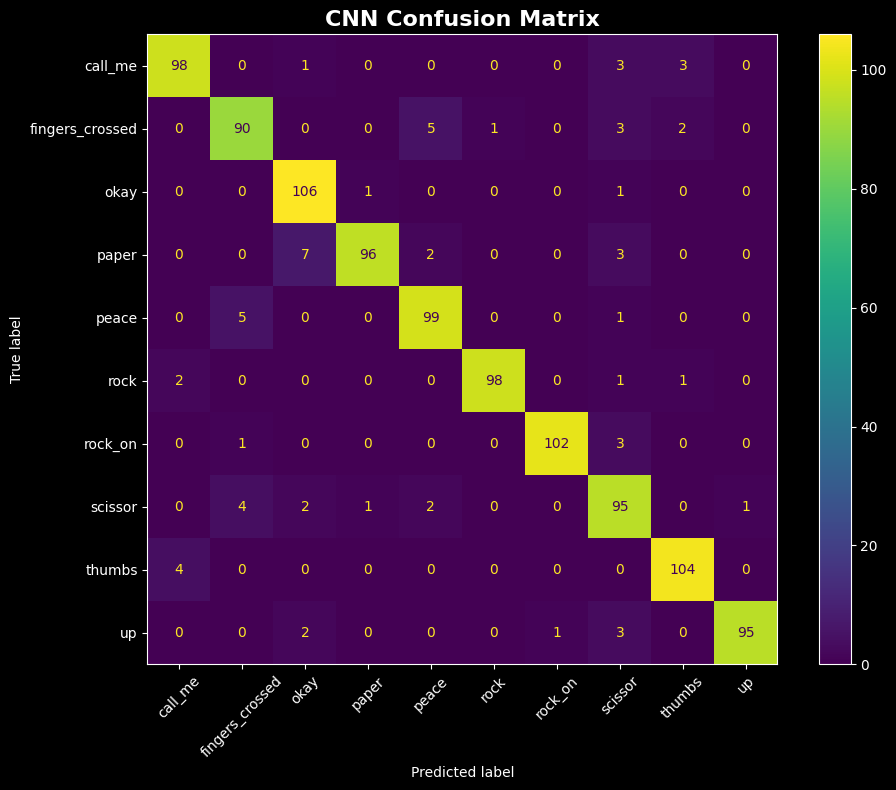

In [31]:
plt.style.use("dark_background")

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    cmap="viridis",
    xticks_rotation=45,
    ax=ax,
    colorbar=True
)

plt.title("CNN Confusion Matrix",
          fontsize=16,
          fontweight="bold")

plt.tight_layout()
plt.show()

plt.style.use("default")

## 💾 Step 21: Save the Trained Model

In [32]:
import os

os.makedirs("model", exist_ok=True)

model.save("model/gesture_model.keras")

print("✅ Model saved successfully!")

✅ Model saved successfully!


## 🏷️ Step 22: Save the Label Encoder

In [33]:
import pickle

with open("model/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("✅ Label Encoder saved successfully!")

✅ Label Encoder saved successfully!


## ✅ Step 23: Verify Saved Files

In [35]:
from pathlib import Path

print("Model Exists :", Path("model/gesture_model.keras").exists())
print("Label Encoder Exists :", Path("model/label_encoder.pkl").exists())

Model Exists : True
Label Encoder Exists : True
